In [1]:
using WaveSpec

Precompiling packages...
   4487.2 ms  ✓ WaveSpec
  1 dependency successfully precompiled in 9 seconds. 209 already precompiled.
[ Info: WaveSpec initialized: Ready for spectral sea state synthesis.


In [32]:
using WaveSpec.ContinuousSpectrums
using WaveSpec.FrequencySampling
using WaveSpec.SpectralSpreading

# --- 1. Discrete Spectrum ---
Hs_target = 3.0
Tp_target = 2.0
h_target  = 30.0
U10_target = 10.0

Hs_target_2 = 1.0
Tp_target_2 = 4.0
λ1 = 2
λ2 = 3

#spec = JONSWAP(Hs_target, Tp_target)
#spec = Bretschneider(Hs_target, Tp_target)
spec = OchiHubble(Hs_target, Tp_target, λ1, Hs_target_2, Tp_target_2, λ2)
nf = 2^13

# Test with Equal Energy sampling to prove the strategy works
ds = DiscreteSpectrum(spec, UniformSampling(), get_fmin(spec), get_fmax(spec), nf; 
                        domain=FrequencyDomain(), mess=false)

DiscreteSpectrum(OchiHubble{Float64}(3.0, 2.0, 2.0, 0.5, 1.0, 4.0, 3.0, 0.25, 3.1622776601683795), UniformSampling(), FrequencyDomain(), 2.5e-5, 1.25, 8192, 8191, 1.0014389505358932)

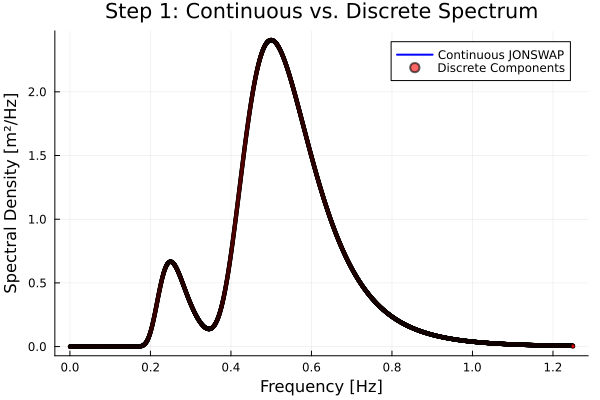

In [33]:
using Plots

# Continuous Curve
f_cont = range(get_fmin(spec), get_fmax(spec), length=1000)
S_cont = [ContinuousSpectrums.get_density(spec, f) for f in f_cont]

p1 = plot(f_cont, S_cont, label="Continuous JONSWAP", lw=2, color=:blue)

# Note: To plot discrete density, we divide variance (A^2/2) by df
freqs = get_frequencies(ds)
amplitudes = get_amplitudes(ds)
df_ds = freqs[2] - freqs[1]
S_discrete = (amplitudes.^2 ./ 2.0) ./ df_ds

scatter!(freqs, S_discrete, label="Discrete Components", markersize=2, alpha=0.6, color=:red)
title!("Step 1: Continuous vs. Discrete Spectrum")
xlabel!("Frequency [Hz]")
ylabel!("Spectral Density [m²/Hz]")

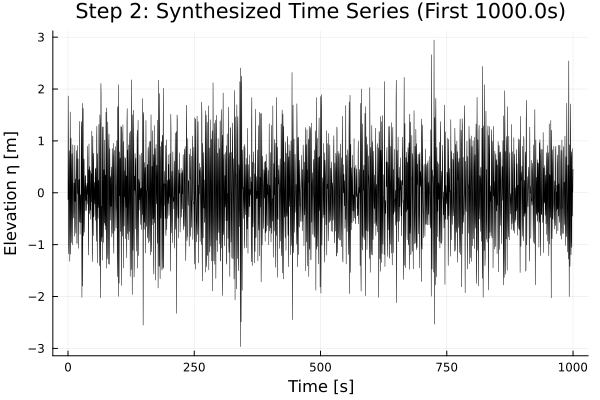

In [34]:
# --- 2. Signal Synthesis ---
# Sampling parameters
N = 2^14                    # Even number (power of 2) of samplings in time (choose high number for long time window)
fs = 2.0 * get_fmax(spec)   # Nyquist frequency (the window sampling frequency fs must be MORE than double the signal maximum frequency -> AVOID ALIASING)
dt = 1.0 / fs
t = collect(0:dt:(N-1)*dt)

amplitudes = SpectralSpreading.get_amplitudes(ds)
freqs = SpectralSpreading.get_central_frequencies(ds)
phases = 2π .* rand(ds.nf)

# η(t) = Σ A_i * cos(2π f_i t + ϕ_i)
eta = zeros(length(t))
for (A, f, ϕ) in zip(amplitudes, freqs, phases)
    eta .+= A .* cos.(2π * f .* t .+ ϕ)
end

# Plotting a subset of the time series for clarity 
T_window = 1000.0
time_mask = t .<= T_window
p2 = plot(t[time_mask], eta[time_mask], color=:black, lw=0.5, legend=false)
title!("Step 2: Synthesized Time Series (First " * string(T_window) * "s)")
xlabel!("Time [s]")
ylabel!("Elevation η [m]")

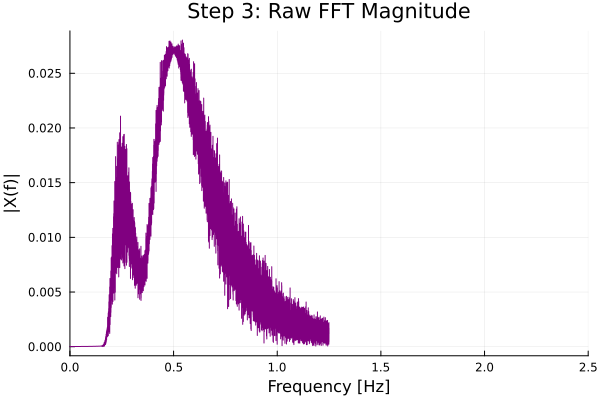

In [35]:
using FFTW

# --- 4. Spectral Validation (Reconstruction) ---
# Perform the signal's Fast Fourier Transform
fft_res = fft(eta)
f_axis = (0:Int(N/2)-1) ./ last(t)

# Raw FFT magnitude
fft_mag = 2.0 * abs.(fft_res[1:Int(N/2)]) / N
p3 = plot(f_axis, fft_mag, color=:purple, legend=false)
title!("Step 3: Raw FFT Magnitude")
xlabel!("Frequency [Hz]")
ylabel!("|X(f)|")
xlims!(0, 2.5)

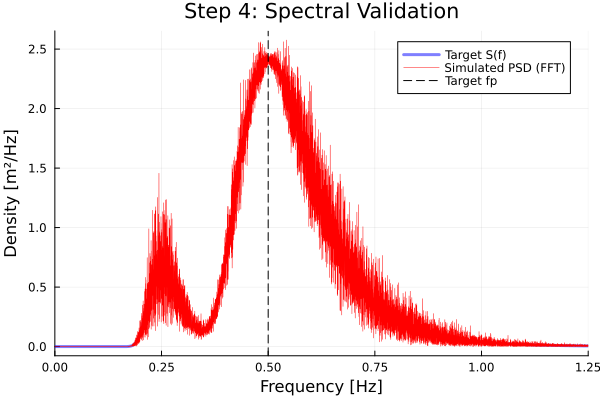

In [36]:
# --- 5. Power Spectral Density (PSD) ---
psd_sim = fft_mag .^ 2 / 2.0 / (f_axis[2] - f_axis[1])

p4 = plot(f_cont, S_cont, label="Target S(f)", lw=3, color=:blue, alpha=0.5)
plot!(f_axis, psd_sim, label="Simulated PSD (FFT)", color=:red, lw=0.5)
title!("Step 4: Spectral Validation")
xlabel!("Frequency [Hz]")
ylabel!("Density [m²/Hz]")
xlims!(0, get_fmax(spec))

# Add a vertical line for Peak Frequency
vline!([1/Tp_target], label="Target fp", line=:dash, color=:black)

In [37]:
using Test 

# the integral of your psd_sim should match your target variance
@test sum(psd_sim .* fs/N) ≈ Hs_target^2 / 16 rtol=1e-2

Test Failed at In[37]:4
  Expression: ≈(sum((psd_sim .* fs) / N), Hs_target ^ 2 / 16, rtol = 0.01)
   Evaluated: 0.6250972044168089 ≈ 0.5625 (rtol=0.01)



LoadError: [91mThere was an error during testing[39m

In [ ]:
# Compare Integrated Energy in Bands.
# For example, check if the energy between $0.8 f_p$ and $1.2 f_p$ is the same in both the model and the simulation:

# Energy in the peak region
mask_sim = (f_axis .> 0.8/Tp_target) .& (f_axis .< 1.2/Tp_target)
energy_sim = sum(psd_sim[mask_sim]) * (f_axis[2] - f_axis[1])

mask_target = (f_cont .> 0.8/Tp_target) .& (f_cont .< 1.2/Tp_target)
energy_target = sum(S_cont[mask_target]) * (f_cont[2] - f_cont[1])

@test energy_sim ≈ energy_target rtol=0.05

Test Passed

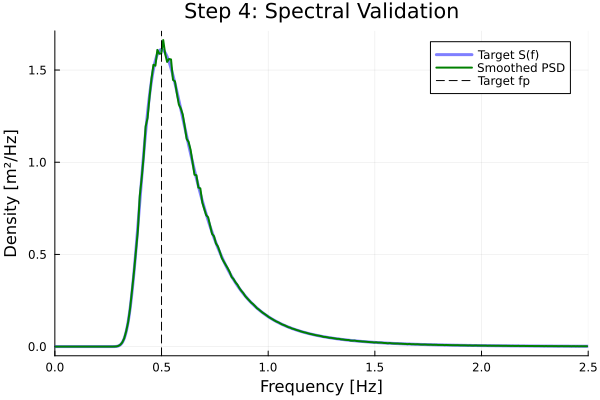

In [ ]:
using Statistics

# This function takes the "spiky" FFT and averages neighboring bins to create a smoother power spectral density

function smooth_psd(f_axis, psd, navg=20)
    n = length(psd)
    n_smooth = div(n, navg)
    f_res = zeros(n_smooth)
    psd_res = zeros(n_smooth)
    
    for i in 1:n_smooth
        idx = ((i-1)*navg + 1):(i*navg)
        f_res[i] = mean(f_axis[idx])
        psd_res[i] = mean(psd[idx])
    end
    return f_res, psd_res
end

# Usage in your plot:
f_smooth, S_smooth = smooth_psd(f_axis, psd_sim, 30)

p4 = plot(f_cont, S_cont, label="Target S(f)", lw=3, color=:blue, alpha=0.5)
plot!(f_smooth, S_smooth, label="Smoothed PSD", lw=2, color=:green)
title!("Step 4: Spectral Validation")
xlabel!("Frequency [Hz]")
ylabel!("Density [m²/Hz]")
xlims!(0, get_fmax(spec))

# Add a vertical line for Peak Frequency
vline!([1/Tp_target], label="Target fp", line=:dash, color=:black)


In [ ]:
# Test 4.4: Check if the recovered peak density matches the target density
S_max_target = ContinuousSpectrums.get_density(spec, 1/Tp_target)
S_max_sim = maximum(S_smooth)

@info "Reconstruction Results" Hs_sim f_peak_sim S_max_sim S_max_target

@test S_max_sim ≈ S_max_target rtol=0.15 

┌ Error: Exception while generating log record in module Main at In[28]:5
│   exception =
│    UndefVarError: `Hs_sim` not defined
│    Stacktrace:
│      [1] logging_error(logger::Any, level::Any, _module::Any, group::Any, id::Any, filepath::Any, line::Any, err::Any, real::Bool)
│        @ Base.CoreLogging ./logging.jl:480
│      [2] invokelatest(::Any, ::Any, ::Vararg{Any}; kwargs::@Kwargs{})
│        @ Base ./essentials.jl:892
│      [3] invokelatest(::Any, ::Any, ::Vararg{Any})
│        @ Base ./essentials.jl:889
│      [4] macro expansion
│        @ logging.jl:366 [inlined]
│      [5] top-level scope
│        @ In[28]:5
│      [6] eval
│        @ ./boot.jl:385 [inlined]
│      [7] include_string(mapexpr::typeof(REPL.softscope), mod::Module, code::String, filename::String)
│        @ Base ./loading.jl:2146
│      [8] execute_request(socket::ZMQ.Socket, kernel::IJulia.Kernel, msg::IJulia.Msg)
│        @ IJulia ~/.julia/packages/IJulia/TXScA/src/execute_request.jl:129
│      [9] #inv

Test Passed

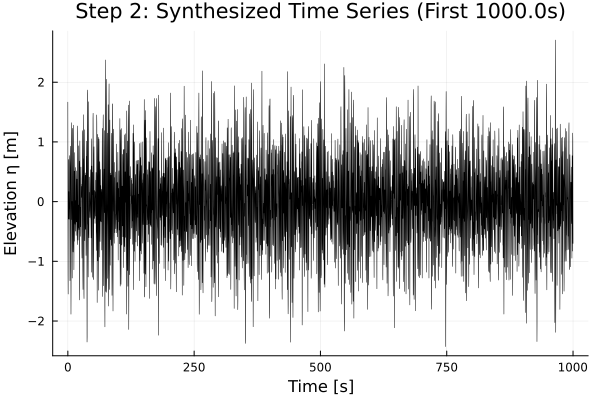

In [ ]:
using WaveSpec.Signal

# Generate Signal
h = 2.0
t, signal = generate_signal(ds, h, N)

# Plotting a subset of the time series for clarity 
T_window = 1000.0
time_mask = t .<= T_window
p2 = plot(t[time_mask], signal[time_mask], color=:black, lw=0.5, legend=false)
title!("Step 2: Synthesized Time Series (First " * string(T_window) * "s)")
xlabel!("Time [s]")
ylabel!("Elevation η [m]")

Sample Length = 16384
Least count Hz = 0.00030517578125
Max Freq (Half band) Hz = 2.5


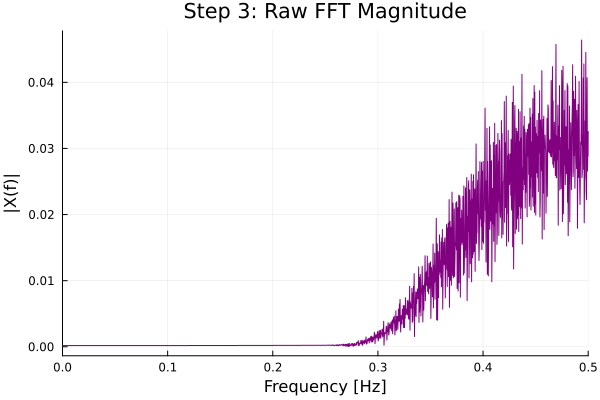

In [ ]:
fHalf, fAmp, psd = get_single_sided_spectrum(signal, fs)

p3 = plot(fHalf, fAmp, color=:purple, legend=false)
title!("Step 3: Raw FFT Magnitude")
xlabel!("Frequency [Hz]")
ylabel!("|X(f)|")
xlims!(0, 0.5)

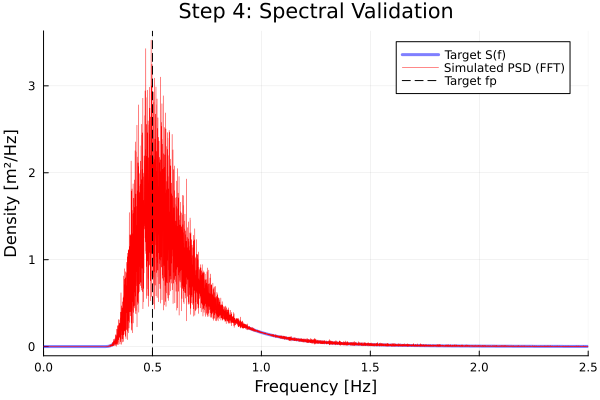

In [ ]:
p4 = plot(f_cont, S_cont, label="Target S(f)", lw=3, color=:blue, alpha=0.5)
plot!(fHalf, psd, label="Simulated PSD (FFT)", color=:red, lw=0.5)
title!("Step 4: Spectral Validation")
xlabel!("Frequency [Hz]")
ylabel!("Density [m²/Hz]")
xlims!(0, get_fmax(spec))

# Add a vertical line for Peak Frequency
vline!([1/Tp_target], label="Target fp", line=:dash, color=:black)